# Can LLMs Find Answers Without Vector Search?

I built two RAG pipelines and tested them head-to-head on 4 questions about a small synthetic PDF on RAG retrieval methods.

**The two approaches:**
- **Vector RAG** — classic chunk-and-embed. Splits the PDF into pieces, converts them to numbers, retrieves the closest matches to the question.
- **PageIndex** — no embeddings. An LLM reads a map of the document and reasons about which sections are relevant.

Both get the same 4 questions. I score every answer manually against the source document. Let's see which one actually works better and *where*.

> Document used: `src/rag_shootout/sample_paper.pdf`


## Step 1 — Setup

Load environment variables (API keys from `.env`) and confirm everything is ready.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

from rag_shootout import config

missing = config.validate_env()
if missing:
    print(f"Missing keys: {missing}")
    print("Copy .env.example to .env and fill in your API keys.")
else:
    print("API keys loaded.")

print(f"LLM model  : {config.MODEL}")
print(f"Embeddings : {config.EMBEDDING_MODEL}")
print(f"Chunk size : {config.CHUNK_SIZE} chars, overlap={config.CHUNK_OVERLAP}, top_k={config.TOP_K}")


API keys loaded.
LLM model  : nvidia/nemotron-3-ultra-550b-a55b:free
Embeddings : all-MiniLM-L6-v2
Chunk size : 800 chars, overlap=150, top_k=5


## Step 2 — Get the Paper

Load the synthetic sample PDF and extract text from each page. The document is short on purpose so the question set, not document length, drives the comparison.


In [2]:
from rag_shootout.pdf_utils import download_pdf, extract_pages, chunk_pages

pdf_path = download_pdf()
pages = extract_pages(pdf_path)

print(f"\nFirst 300 characters of page 1:")
print(pages[0]["text"][:300])


[PDF] Using cached file: C:\Users\hp\Downloads\rag-shootout (1)\rag-shootout\src\rag_shootout\sample_paper.pdf (2 KB)
[PDF] Extracted text from 1 pages (sample_paper.pdf)

First 300 characters of page 1:
Retrieval Augmented Generation, or RAG, is a pattern for giving a language model access
to external knowledge at answer time. Instead of relying only on what the model
memorized during training, a RAG system first retrieves passages from a source document
or knowledge base, then supplies that materi


## Step 3 — Chop the PDF into Chunks (Vector RAG only)

Vector RAG needs the text broken into small pieces before it can embed them. I'm using 800-character chunks with 150-character overlap so sentences don't get cut off at boundaries.

PageIndex doesn't need this step — it works on the whole document.


In [3]:
import sys
print(sys.executable)

c:\Users\hp\Downloads\rag-shootout (1)\rag-shootout\.venv\Scripts\python.exe


In [4]:
chunks = chunk_pages(pages)

print(f"\nExample chunk (chunk #5):")
print("-" * 60)
print(chunks[-1]["text"])
print("-" * 60)
print(f"From page {chunks[-1]['page']}")


[Chunk] Created 3 chunks (size=800, overlap=150) from 1 pages

Example chunk (chunk #5):
------------------------------------------------------------
ctions and can make navigation more faithful to how long documents are written. In practice, vector search is often strongest when a question can be matched directly to a compact passage, while hierarchical retrieval is often stronger when the answer depends on document layout, section boundaries, or reasoning across related parts of the text. Vector methods are usually simpler to build and scale, but structure aware methods can better reflect how a document is organized. The better choice depends on whether semantic closeness or document structure matters more for the task.
------------------------------------------------------------
From page 1


## Step 4 — Build the Vector RAG Pipeline

This embeds all the chunks using `all-MiniLM-L6-v2` (a small but solid sentence embedding model). When a question comes in, it embeds the question the same way and finds the 5 chunks with the highest cosine similarity.

The embedding step takes about 30–60 seconds on first run (downloading the model). After that it's fast.


In [5]:
from rag_shootout.vector_pipeline import VectorRAGPipeline

vector = VectorRAGPipeline()
vector.index(chunks)


c:\Users\hp\Downloads\rag-shootout (1)\rag-shootout\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[VectorRAG] Loading embedder: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5096.84it/s]


[VectorRAG] Embedding 3 chunks ...


Batches: 100%|██████████| 1/1 [00:00<00:00,  9.19it/s]

[VectorRAG] Index ready — shape: (3, 384)


Quick test to make sure retrieval is working:

In [6]:
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(Path("..") / ".env")

True

In [7]:
from rag_shootout import config

print(config.OPENROUTER_API_KEY[:12] + "...")

sk-or-v1-c2a...


In [8]:
result = vector.answer("How does vector search retrieve relevant information?")

print(f"Retrieved from pages: {result['pages_retrieved']}")
print(f"Response time: {result['time_sec']}s")
print()
print(result["answer"])


Retrieved from pages: [1]
Response time: 6.629s

Vectorsearch retrieves relevant information by converting both documents and user questions into embeddings (numeric representations that place similar meanings near each other in high-dimensional space). At query time, the system embeds the question, compares it against stored document vectors, and returns the chunks with the highest similarity scores. This approach is fast and flexible, especially when the wording in the query does not exactly match the wording in the document.


## Step 5 — Set Up PageIndex

This uploads the PDF to PageIndex, which builds a tree structure of the document. That structure is what the LLM reasons over when deciding which sections to retrieve.

**This takes 1–3 minutes on first upload.** After that you can reuse the `doc_id` to skip re-uploading.


In [9]:
from rag_shootout.pageindex_pipeline import PageIndexPipeline

pageindex = PageIndexPipeline()
pageindex.submit(pdf_path)


[PageIndex] Submitting C:\Users\hp\Downloads\rag-shootout (1)\rag-shootout\src\rag_shootout\sample_paper.pdf ...
[PageIndex] Document ID: pi-cmqwpasyg016w01pex3umrizd
[PageIndex] Waiting for tree generation (1-3 min) ...
[PageIndex] Status: processing ...
[PageIndex] Status: completed, retrieval not ready yet ...
[PageIndex] Status: completed, retrieval not ready yet ...
[PageIndex] Status: completed, retrieval not ready yet ...
[PageIndex] Tree generation complete.


'pi-cmqwpasyg016w01pex3umrizd'

Quick test:

In [10]:
result_pi = pageindex.answer("How does tree-based retrieval navigate a document?")

print(f"Response time: {result_pi['time_sec']}s")
print()
print(result_pi["answer"])


Response time: 17.254s

According to the document, **tree-based (hierarchical) retrieval** navigates a document as follows:

1. **Pre-structures the document** — Before answering any query, it organizes the document into a hierarchy (e.g., sections, subsections, pages, or parent-child summaries).

2. **Uses a document map** — Instead of relying purely on local semantic similarity, the retriever traverses this map to identify which *branches* of the hierarchy are relevant.

3. **Drills down from broad to specific** — It moves from high-level topics progressively into more specific evidence, following the document's logical structure.

4. **Preserves section relationships** — By respecting boundaries between sections and how parts relate to each other, it keeps navigation faithful to how the document was actually written.

This makes it especially effective when an answer spans multiple related sections or depends on the document's layout, as opposed to vector search which excels at matc

## Step 6 — The 4 Questions

These aren't random questions. Each one is chosen to stress a specific weakness in retrieval systems:

| Type | The challenge |
|---|---|
| Simple factual | Baseline — if both fail here, something's wrong |
| Exact number | Numbers often get split across chunk boundaries |
| Full pipeline | Answer is spread across 5+ sections |
| Buried story | One paragraph, deep in the paper |


In [11]:
from rag_shootout.questions import get_questions

questions = get_questions()
for q in questions:
    print(f"Q{q.id:2d}  [{q.category}]")
    print(f"    {q.text}")
    print()


Q 1  [Vector Match]
    How does vector search retrieve relevant information?

Q 2  [Structure Navigation]
    How does tree-based retrieval navigate a document?

Q 3  [Limitations]
    What are the limitations of vector similarity search?

Q 4  [Comparison]
    Which retrieval method better understands document structure?



## Step 7 — Run the Comparison

Both pipelines answer all 4 questions. This will take a few minutes because of API latency. I print both answers side by side so you can read them against the document and score them in the next step.


In [12]:
import time

results = []

for q in questions:
    print("=" * 70)
    print(f"Q{q.id}  [{q.category}]")
    print(q.text)
    print("=" * 70)

    v = vector.answer(q.text)
    print(f"\nVECTOR RAG  ({v['time_sec']}s | pages {v['pages_retrieved']})")

    if not v["answer"]:
        print("[VECTOR RAG] Empty response — skipping question (API may have returned nothing)")
        continue

    print(v["answer"][:600])

    try:
        p = pageindex.answer(q.text)
        print(f"\nPAGEINDEX  ({p['time_sec']}s | doc_id={p.get('doc_id')})")
        print(p["answer"][:600])
        print("\nPAGEINDEX RAW RESPONSE")
        print(p.get("raw_response", "")[:1000])
    except Exception as exc:
        print("\nPAGEINDEX ERROR")
        print(repr(exc))
        raise
    print()

    results.append({
        "question_id": q.id,
        "category": q.category,
        "question": q.text,
        "vector_answer": v["answer"],
        "vector_time": v["time_sec"],
        "vector_pages": v["pages_retrieved"],
        "pageindex_answer": p["answer"],
        "pageindex_time": p["time_sec"],
    })

    time.sleep(2)

print(f"Done — {len(results)} questions answered by both pipelines.")


Q1  [Vector Match]
How does vector search retrieve relevant information?

VECTOR RAG  (24.519s | pages [1])
Vector search retrieves relevant information by converting both documents and user questions into embeddings—numeric representations that place similar meanings near each other in a high-dimensional space. At query time, the system embeds the question, compares it against stored document vectors, and returns the chunks with the highest similarity scores. This approach is fast and flexible, especially when the wording in the query does not exactly match the wording in the document.

PAGEINDEX  (11.037s | doc_id=pi-cmqwpasyg016w01pex3umrizd)
Based on the document, here's how vector search retrieves relevant information:

1. **Embedding conversion**: Both the documents and the user's query are converted into **embeddings** — numeric representations that place semantically similar content close together in a high-dimensional space.

2. **Query-time matching**: When a question is aske

## Step 8 — Score Each Answer

Open the paper in another tab and score every answer 1–5 on three things:

| Dimension | 1 means... | 5 means... |
|---|---|---|
| **Accuracy** | The answer is factually wrong | Everything is correct |
| **Completeness** | It missed the point | It covered everything asked |
| **Faithfulness** | It made things up | Every claim is in the document |

Fill in the scores below, then re-run the cells underneath to see the results.


In [20]:
from rag_shootout.scoring import make_empty_scorecard, DimensionScore, scores_to_dataframe, print_summary

scorecard = make_empty_scorecard(n_questions=4)

# ── Fill in your scores here ──────────────────────────────────────────────
scorecard[0].vector    = DimensionScore(accuracy=5, completeness=5, faithfulness=5)
scorecard[0].pageindex = DimensionScore(accuracy=5, completeness=4, faithfulness=5)

scorecard[1].vector    = DimensionScore(accuracy=3, completeness=3, faithfulness=4)
scorecard[1].pageindex = DimensionScore(accuracy=5, completeness=5, faithfulness=5)

scorecard[2].vector    = DimensionScore(accuracy=4, completeness=3, faithfulness=4)
scorecard[2].pageindex = DimensionScore(accuracy=4, completeness=5, faithfulness=4)

scorecard[3].vector    = DimensionScore(accuracy=3, completeness=3, faithfulness=3)
scorecard[3].pageindex = DimensionScore(accuracy=5, completeness=5, faithfulness=5)
# ─────────────────────────────────────────────────────────────────────────

scored = sum(1 for s in scorecard if s.vector.is_complete() and s.pageindex.is_complete())
print(f"Scored so far: {scored} / {len(scorecard)} questions")
print("Fill in the DimensionScore lines above from the actual answers, then run the next cells.")


Scored so far: 4 / 4 questions
Fill in the DimensionScore lines above from the actual answers, then run the next cells.


In [16]:
df = scores_to_dataframe(scorecard, results)
print_summary(scorecard)



  RAG SHOOTOUT RESULTS — 4 questions scored

Vector RAG:
  Total score:    45.0 / 60
  Avg per Q:      11.25 / 15
  Accuracy avg:   3.75
  Completeness:   3.5
  Faithfulness:   4.0

PageIndex:
  Total score:    57.0 / 60
  Avg per Q:      14.25 / 15
  Accuracy avg:   4.75
  Completeness:   4.75
  Faithfulness:   4.75

Wins → Vector RAG: 1 | PageIndex: 3 | Tie: 0



In [21]:
df[["category", "winner", "vector_total", "pageindex_total", "vector_time", "pageindex_time"]]


,category,winner,vector_total,pageindex_total,vector_time,pageindex_time
0,Vector Match,Vector RAG,15.0,14.0,24.519,11.037
1,Structure Navigation,PageIndex,10.0,15.0,4.967,11.434
2,Limitations,PageIndex,11.0,13.0,55.259,12.765
3,Comparison,PageIndex,9.0,15.0,3.877,9.980


## Step 9 — Charts

Four views of the same data. The most interesting one is usually the last — wins broken down by question type, which shows *where* each approach is actually better.


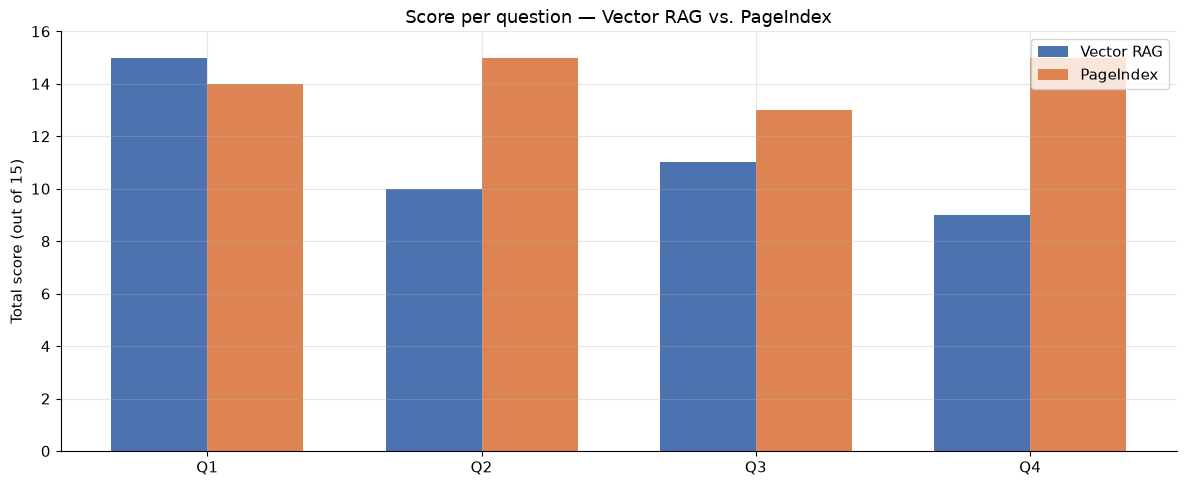

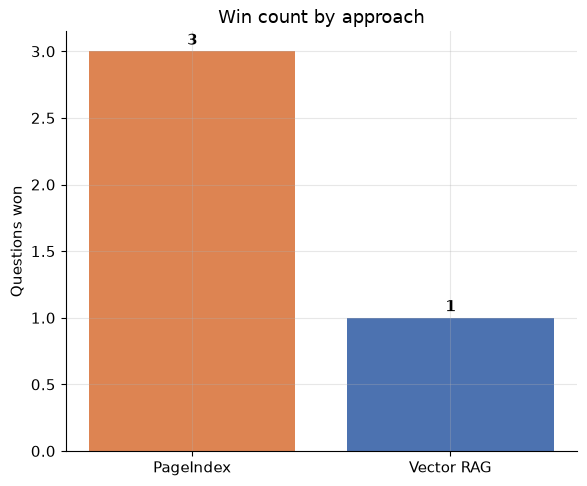

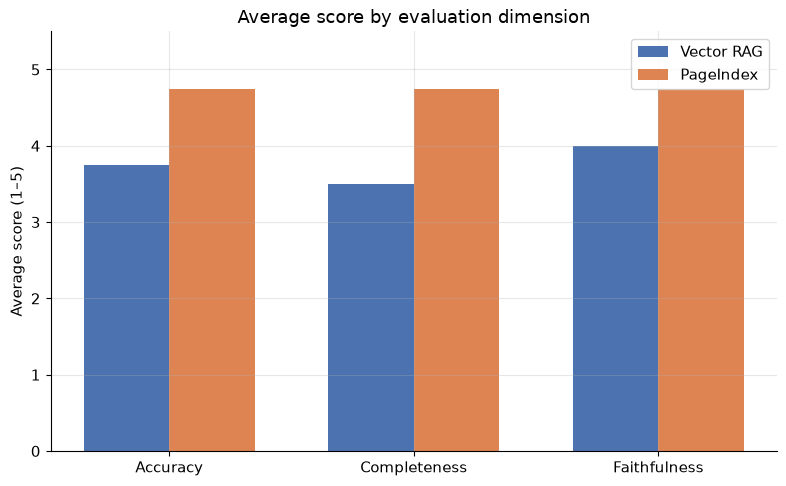

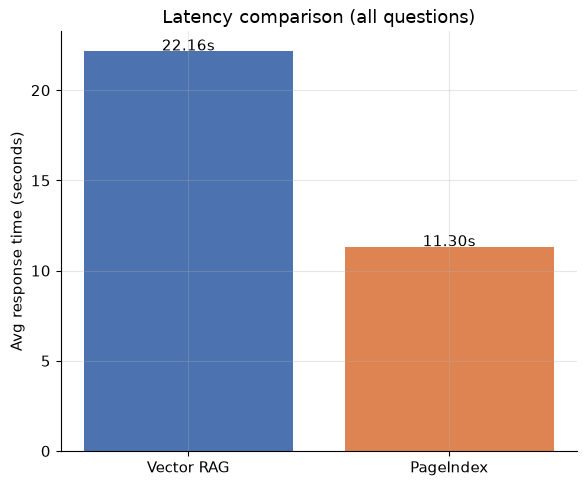

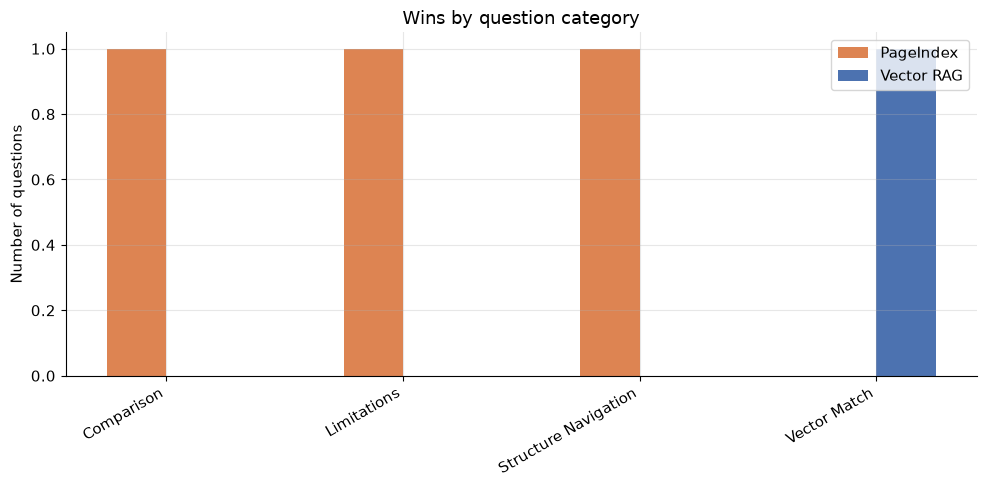

In [22]:
import matplotlib.pyplot as plt
from rag_shootout.visualization import (
    plot_scores_per_question,
    plot_win_counts,
    plot_dimension_averages,
    plot_latency,
    plot_wins_by_category,
)

for fn in [plot_scores_per_question, plot_win_counts, plot_dimension_averages, plot_latency, plot_wins_by_category]:
    try:
        fig = fn(df)
        plt.show()
    except (ValueError, KeyError) as e:
        print(f"Skipped {fn.__name__} — score more questions first. ({e})")


## Step 10 — Save Results

In [23]:
from rag_shootout.config import RESULTS_DIR

out = RESULTS_DIR / "benchmark_results.csv"
df.to_csv(out, index=False)
print(f"Saved to {out}")


Saved to C:\Users\hp\Downloads\rag-shootout (1)\rag-shootout\results\benchmark_results.csv


## My Takeaways


---

*If you want to try this on a different document, change `PDF_URL` and `PDF_PATH` in `src/rag_shootout/config.py` and swap in your own questions in `src/rag_shootout/questions.py`.*
